### Imbalance Problem


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df=pd.read_csv("decision_tree_dataset.csv")

In [39]:
df

,age,income,credit_score,city,gender,purchases,loan_amount,approved
0,41,16832.970365,646.435852,Hyderabad,Female,2,NaN,0
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.369348,0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.063625,0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.286243,0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.809910,0
...,...,...,...,...,...,...,...,...
1045,57,86596.286095,548.490581,Bangalore,Male,3,124867.554418,0
1046,67,55567.188101,NaN,Delhi,Female,4,19776.528421,1
1047,43,57155.612408,773.613072,Mumbai,Female,1,195876.623311,0
1048,60,35425.789422,549.604263,Mumbai,Male,4,115295.988140,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1050 non-null   int64  
 1   income        947 non-null    float64
 2   credit_score  946 non-null    float64
 3   city          1050 non-null   object 
 4   gender        1050 non-null   object 
 5   purchases     1050 non-null   int64  
 6   loan_amount   947 non-null    float64
 7   approved      1050 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 65.8+ KB


In [41]:
df.describe()

,age,income,credit_score,purchases,loan_amount,approved
count,1050.000000,947.000000,946.000000,1050.000000,9.470000e+02,1050.000000
mean,43.737143,55807.648029,651.605495,2.934286,2.086066e+05,0.303810
std,15.021797,40021.647680,100.166162,1.603281,1.270517e+05,0.460121
min,18.000000,6556.169327,348.048784,0.000000,-5.768131e+04,0.000000
25%,31.000000,40886.541936,584.998140,2.000000,1.378232e+05,0.000000
50%,44.000000,50967.116222,650.052796,3.000000,1.971923e+05,0.000000
75%,56.000000,60643.014837,718.563117,4.000000,2.598691e+05,1.000000
max,69.000000,445126.233564,969.310757,9.000000,1.233105e+06,1.000000


In [42]:
df.isnull().sum()

age               0
income          103
credit_score    104
city              0
gender            0
purchases         0
loan_amount     103
approved          0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(50)

<Axes: >

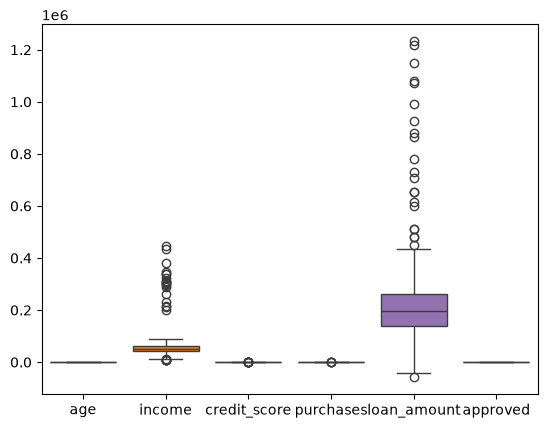

In [44]:
sns.boxplot(df)

### Data Preprocessing

In [45]:
# fill the missing values
inc_med=df["income"].median()
df["income"]=df["income"].fillna(inc_med)

loan_med=df["loan_amount"].median()
df["loan_amount"]=df["loan_amount"].fillna(loan_med)

cred_mean=df["credit_score"].median()
df["credit_score"]=df["credit_score"].fillna(cred_mean)



In [46]:
# handel the utliers
out_columns=["income","credit_score","loan_amount"]

for col in out_columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)

IQR=q3=q1

LB=q1-1.5*IQR
UB=q3+1.5*IQR

df[col]=df[col].clip(lower=LB,upper=UB)

In [47]:
df.drop("city",axis=1,inplace=True)

In [48]:
df["gender"]=df["gender"].replace({
    "Male":1,
    "Female":0})

C:\Users\vaish\AppData\Local\Temp\ipykernel_15696\2555199259.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"]=df["gender"].replace({


In [49]:
df["gender"]

0       0
1       0
2       1
3       0
4       1
       ..
1045    1
1046    0
1047    0
1048    1
1049    1
Name: gender, Length: 1050, dtype: int64

In [50]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1050 non-null   int64  
 1   income        1050 non-null   float64
 2   credit_score  1050 non-null   float64
 3   gender        1050 non-null   int64  
 4   purchases     1050 non-null   int64  
 5   loan_amount   1050 non-null   float64
 6   approved      1050 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 57.6 KB


### Model Training

In [51]:
# splitting columns

X=df.drop("approved",axis=1)
y=df["approved"]

random oversampling


In [ ]:
from imblearn.over_sampling import RandomOverSampler

 # instance
ros=RandomOverSampler(random_state=42)

# # ?fit and transfrom

X_resampled,y_resampled=ros.fit(X,y)


In [ ]:
from sklearn.model_selection import train_test_split
X_train_resampled,X_test_resampled,y_train_resampled,y_test_resampled=train_test_split(X,y,test_size=0.2,random_state=42)

### SMOTE

In [57]:
from imblearn.over_sampling import SMOTE


smote=SMOTE(random_state=42)

X_resampled,y_resampled=smote.fit_resample(X,y)

In [59]:
# model building
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

LR=LogisticRegression()

model=LR.fit(X_train,y_train)

y_pred=model.predict(X_test)


c:\Users\vaish\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Accuracy score

from sklearn.linear_model import 